# **Context**
This Online Retail II dataset contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.


# **Attribute Information:**

* InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction.
  * If this code starts with the letter 'c', it indicates a cancellation.
* StockCode: Product (item) code. Nominal.
  * A 5-digit integral number uniquely assigned to each distinct product.
* Description: Product (item) name. Nominal.
* Quantity: The quantities of each product (item) per transaction. Numeric.
* InvoiceDate: Invice date and time. Numeric.
  * The day and time when a transaction was generated.
* UnitPrice: Unit price. Numeric.
  * Product price per unit in sterling (Â£).
* CustomerID: Customer number. Nominal.
  * A 5-digit integral number uniquely assigned to each customer.
* Country: Country name. Nominal.  
  * The name of the country where a customer resides.

# **Data Engineer (Ingestion & Storage)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Initialize PySpark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DemandForecasting") \
    .getOrCreate()

##Load Dataset

In [ ]:
df = spark.read.csv("/content/drive/MyDrive/online_retail_II.csv",header=True, inferSchema=True)
df.printSchema()
df.show(5)

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: double (nullable = true)
 |-- Country: string (nullable = true)

+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00| 6.95|    13085.0|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|    22041|"RECORD FRAME 7""...|      4

## Checks before cleaning

In [ ]:
df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: double (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
df.show(5)

+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00| 6.95|    13085.0|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|    22041|"RECORD FRAME 7""...|      48|2009-12-01 07:45:00|  2.1|    13085.0|United Kingdom|
| 489434|    21232|STRAWBERRY CERAMI...|      24|2009-12-01 07:45:00| 1.25|    13085.0|United Kingdom|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
only showing top 5 rows


In [ ]:
# Dataset Size
df.count()

1067371

In [ ]:
#Check Null Values
from pyspark.sql.functions import col, sum
df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|Invoice|StockCode|Description|Quantity|InvoiceDate|Price|Customer ID|Country|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|      0|        0|       4382|       0|          0|    0|     243007|      0|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+



In [ ]:
#Check Unique Values (Cardinality)
from pyspark.sql.functions import countDistinct
df.select(
    countDistinct("Invoice").alias("Invoices"),
    countDistinct("StockCode").alias("Products"),
    countDistinct("Customer ID").alias("Customers"),
    countDistinct("Country").alias("Countries")
).show()

+--------+--------+---------+---------+
|Invoices|Products|Customers|Countries|
+--------+--------+---------+---------+
|   53628|    5305|     5942|       43|
+--------+--------+---------+---------+



In [ ]:
#Check Duplicates
df.groupBy(df.columns).count().filter("count > 1").show()

+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+-----+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|count|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+-----+
| 492542|    20935| ROUND CACTUS CANDLE|       1|2009-12-17 13:38:00| 2.95|    15889.0|United Kingdom|    2|
| 492751|   84510B|SET OF 4 FAIRY CA...|       1|2009-12-18 13:46:00| 1.25|    15768.0|United Kingdom|    2|
| 494359|    20828|GLITTER BUTTERFLY...|       1|2010-01-13 15:24:00| 2.55|    17962.0|United Kingdom|    2|
| 496313|    21121|SET/10 RED SPOTTY...|       1|2010-01-31 12:15:00| 1.25|    15013.0|United Kingdom|    2|
| 491657|   17164D|ASS COL SMALL SAN...|       6|2009-12-13 11:02:00| 0.42|       NULL|United Kingdom|    2|
| 497216|    21166|COOK WITH WINE ME...|       3|2010-02-07 14:27:00| 1.95|    14685.0|United Kingdom|    2|
| 497512|    20983|

In [ ]:
#Check Negative & Zero Values
df.filter(col("Quantity") <= 0).count()

22950

In [ ]:
#Check Negative & Zero Values
df.filter(col("Price") <= 0).count()


6207

In [ ]:
#Check Cancellation Transactions
df.filter(col("Invoice").startswith("C")).count()

19494

In [ ]:
#Date Range Check
from pyspark.sql.functions import min, max

df.select(
    min("InvoiceDate"),
    max("InvoiceDate")
).show()

+-------------------+-------------------+
|   min(InvoiceDate)|   max(InvoiceDate)|
+-------------------+-------------------+
|2009-12-01 07:45:00|2011-12-09 12:50:00|
+-------------------+-------------------+



In [ ]:
#Distribution of Quantity
df.describe(["Quantity"]).show()

+-------+------------------+
|summary|          Quantity|
+-------+------------------+
|  count|           1067371|
|   mean|   9.9388984711033|
| stddev|172.70579407675524|
|    min|            -80995|
|    max|             80995|
+-------+------------------+



In [ ]:
#Top Countries
df.groupBy("Country").count().orderBy(col("count").desc()).show()

+---------------+------+
|        Country| count|
+---------------+------+
| United Kingdom|981330|
|           EIRE| 17866|
|        Germany| 17624|
|         France| 14330|
|    Netherlands|  5140|
|          Spain|  3811|
|    Switzerland|  3189|
|        Belgium|  3123|
|       Portugal|  2620|
|      Australia|  1913|
|Channel Islands|  1664|
|          Italy|  1534|
|         Norway|  1455|
|         Sweden|  1364|
|         Cyprus|  1176|
|        Finland|  1049|
|        Austria|   938|
|        Denmark|   817|
|    Unspecified|   756|
|         Greece|   663|
+---------------+------+
only showing top 20 rows


In [ ]:
#Check Time Patterns (before aggregation)
from pyspark.sql.functions import to_date

df.withColumn("date", to_date("InvoiceDate")) \
  .groupBy("date") \
  .count() \
  .orderBy("date") \
  .show()

+----------+-----+
|      date|count|
+----------+-----+
|2009-12-01| 3223|
|2009-12-02| 3277|
|2009-12-03| 3002|
|2009-12-04| 2559|
|2009-12-05|  402|
|2009-12-06| 1942|
|2009-12-07| 2869|
|2009-12-08| 2440|
|2009-12-09| 2470|
|2009-12-10| 2492|
|2009-12-11| 1542|
|2009-12-13| 1776|
|2009-12-14| 4117|
|2009-12-15| 2004|
|2009-12-16| 3216|
|2009-12-17| 1965|
|2009-12-18| 2057|
|2009-12-20|  637|
|2009-12-21|  645|
|2009-12-22| 2053|
+----------+-----+
only showing top 20 rows


##Data Cleaning

In [ ]:
#Fix Column Name
df = df.withColumnRenamed("Customer ID", "CustomerID")

In [ ]:
#Remove Cancellation Transactions
from pyspark.sql.functions import col
df = df.filter(~col("Invoice").startswith("C"))

In [ ]:
#Remove Invalid Quantities
df = df.filter(col("Quantity") > 0)

In [ ]:
#Remove Invalid Prices
df = df.filter(col("Price") > 0)

In [ ]:
# Handle Missing Values
df = df.dropna(subset=["Description"])

In [ ]:
df = df.dropna(subset=["CustomerID"])

In [ ]:
#convert into integer
from pyspark.sql.functions import col
df = df.withColumn("CustomerID", col("CustomerID").cast("int"))

In [ ]:
#Remove Duplicates
df = df.dropDuplicates()

In [ ]:
#Handle Outliers
upper_bound = df.approxQuantile("Quantity", [0.99], 0.01)[0]
df = df.filter(col("Quantity") <= upper_bound)

* Extreme values in quantity were detected (max = 80,995).
* To avoid distortion in model training, outliers were removed using the 99th percentile threshold.

In [ ]:
#Convert Date
from pyspark.sql.functions import to_date
df = df.withColumn("date", to_date("InvoiceDate"))

In [ ]:
#Create Revenue
df = df.withColumn("Revenue", col("Quantity") * col("Price"))

* measure total sales value

In [ ]:
#CREATE DEMAND DATASET
from pyspark.sql.functions import sum
df_daily = df.groupBy("date", "StockCode") \
    .agg(sum("Quantity").alias("daily_demand"))

* A demand dataset is: A dataset that shows how much of each product was sold over time

* (raw data): Each row = one transaction
  * Invoice | StockCode | Quantity | InvoiceDate
  * Product A → sold 2 at 10:00  
  * Product A → sold 3 at 12:00  
  * Same product appears MANY times per day; Not suitable for forecasting

* Aggregate (combine) all transactions per day:
  * date       | StockCode | daily_demand
  * 2020-01-01 | A         | 5

* Forecasting needs ONLY: time + product + demand

1. date: Time (day)
2. StockCode: Product ID
3. daily_demand: Total quantity sold that day

* So project uses TWO datasets
1. Raw dataset (original): EDA (analysis), Business insights
2. Demand dataset (processed): Forecasting, Machine learning, Time-series modeling

## Store in dist systems


In [ ]:
df_daily = df_daily.repartition(10, "StockCode")

 * What is repartition?
   * Spark splits data into chunks (partitions) to make processing faster and parallel
   * Split data into 10 parts
   * Group similar products together in same partition
   * Too few partitions → slow
   * Too many partitions → overhead
   * repartition() DOES NOT save anything
   * It only affects Spark execution in memory

In [ ]:
#Sort Data (important for time series)
df_daily = df_daily.orderBy("StockCode", "date")

In [ ]:
#Local Data Lake (Parquet)
df_daily.write.mode("overwrite").parquet("/content/drive/MyDrive/demand_data")


* Data was stored in Parquet format, which simulates a data lake structure for efficient storage and processing.
* automatically partitions the dataset into multiple files to enable distributed processing and scalability.

## Checking again

In [ ]:
df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- date: date (nullable = true)
 |-- Revenue: double (nullable = true)



In [ ]:
#Check schema
df_daily.printSchema()

root
 |-- date: date (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- daily_demand: long (nullable = true)



In [ ]:
#Check nulls
from pyspark.sql.functions import col, sum

df_daily.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df_daily.columns
]).show()


+----+---------+------------+
|date|StockCode|daily_demand|
+----+---------+------------+
|   0|        0|           0|
+----+---------+------------+



In [ ]:
#Check duplicates
df_daily.groupBy("date", "StockCode") \
    .count() \
    .filter("count > 1") \
    .show()

+----+---------+-----+
|date|StockCode|count|
+----+---------+-----+
+----+---------+-----+



In [ ]:
#Check negative demand
df_daily.filter(col("daily_demand") <= 0).show()

+----+---------+------------+
|date|StockCode|daily_demand|
+----+---------+------------+
+----+---------+------------+



In [ ]:
#Check date range
from pyspark.sql.functions import min, max
df_daily.select(min("date"), max("date")).show()

+----------+----------+
| min(date)| max(date)|
+----------+----------+
|2009-12-01|2011-12-09|
+----------+----------+



In [ ]:
#Check number of products
df_daily.select("StockCode").distinct().count()

4631

In [ ]:
#Sample data
df_daily.orderBy("date").show(10)


+----------+---------+------------+
|      date|StockCode|daily_demand|
+----------+---------+------------+
|2009-12-01|    84855|           2|
|2009-12-01|    84987|           3|
|2009-12-01|    22090|          12|
|2009-12-01|   16207A|           3|
|2009-12-01|    20828|          13|
|2009-12-01|    22102|           3|
|2009-12-01|    20971|          19|
|2009-12-01|    37502|          17|
|2009-12-01|    21934|           3|
|2009-12-01|    21754|          53|
+----------+---------+------------+
only showing top 10 rows


# **Data Analyst (Exploration & Insights)**

In [ ]:
df.write.mode("overwrite").option("header", True).csv("/content/drive/MyDrive/processed_df")

In [ ]:
#Load Data
df = spark.read.parquet("/content/drive/MyDrive/demand_data")

In [ ]:
#Total Sales Over Time
from pyspark.sql.functions import sum

daily_sales = df.groupBy("date") \
    .agg(sum("daily_demand").alias("total_sales")) \
    .orderBy("date")

daily_sales.show()

+----------+-----------+
|      date|total_sales|
+----------+-----------+
|2009-12-01|      24335|
|2009-12-02|      29679|
|2009-12-03|      48009|
|2009-12-04|      19954|
|2009-12-05|       5119|
|2009-12-06|      11502|
|2009-12-07|      15557|
|2009-12-08|      22241|
|2009-12-09|      15881|
|2009-12-10|      22534|
|2009-12-11|      21212|
|2009-12-13|      12205|
|2009-12-14|      40815|
|2009-12-15|      26401|
|2009-12-16|      22044|
|2009-12-17|      15031|
|2009-12-18|      15225|
|2009-12-20|       6236|
|2009-12-21|       8446|
|2009-12-22|      11913|
+----------+-----------+
only showing top 20 rows


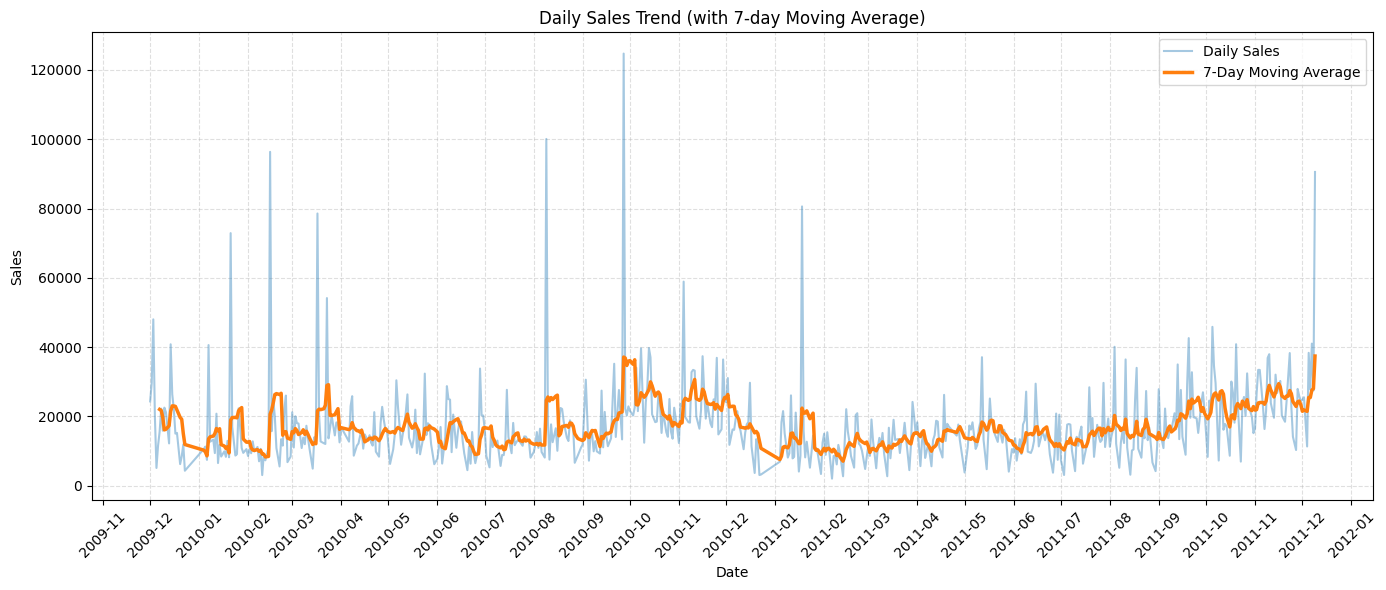

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pdf = daily_sales.toPandas()

# Optional: smooth trend (7-day rolling average)
pdf["rolling_avg"] = pdf["total_sales"].rolling(window=7).mean()

plt.figure(figsize=(14,6))

# Raw sales (light line)
plt.plot(pdf["date"], pdf["total_sales"], alpha=0.4, label="Daily Sales")

# Smoothed trend (main line)
plt.plot(pdf["date"], pdf["rolling_avg"], linewidth=2.5, label="7-Day Moving Average")

# Title + labels
plt.title("Daily Sales Trend (with 7-day Moving Average)")
plt.xlabel("Date")
plt.ylabel("Sales")

# Better date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())   # monthly ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

# Grid for readability
plt.grid(True, linestyle="--", alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()

* each point is:Total sales for ONE specific day
* “How does sales change day by day over time?”
1. Overall trend: Are sales going up over time?
2. Spikes (sudden increases): Big jumps = promotions, holidays, special events,...
3. Drops: Low sales days = weekends, outages, low demand periods
4. Noise (important insight): Daily data is very noisy
* That’s why we use moving average smoothing
* Dates crowded on x-axis: No clear pattern visible to the eye

In [ ]:
#Monthly Seasonality
from pyspark.sql.functions import month
monthly_sales = df.withColumn("month", month("date")) \
    .groupBy("month") \
    .agg(sum("daily_demand").alias("sales")) \
    .orderBy("month")

monthly_sales.show()

+-----+-------+
|month|  sales|
+-----+-------+
|    1| 718555|
|    2| 636888|
|    3| 849682|
|    4| 641953|
|    5| 757824|
|    6| 752886|
|    7| 691992|
|    8| 849915|
|    9|1110805|
|   10|1187975|
|   11|1318991|
|   12| 996486|
+-----+-------+



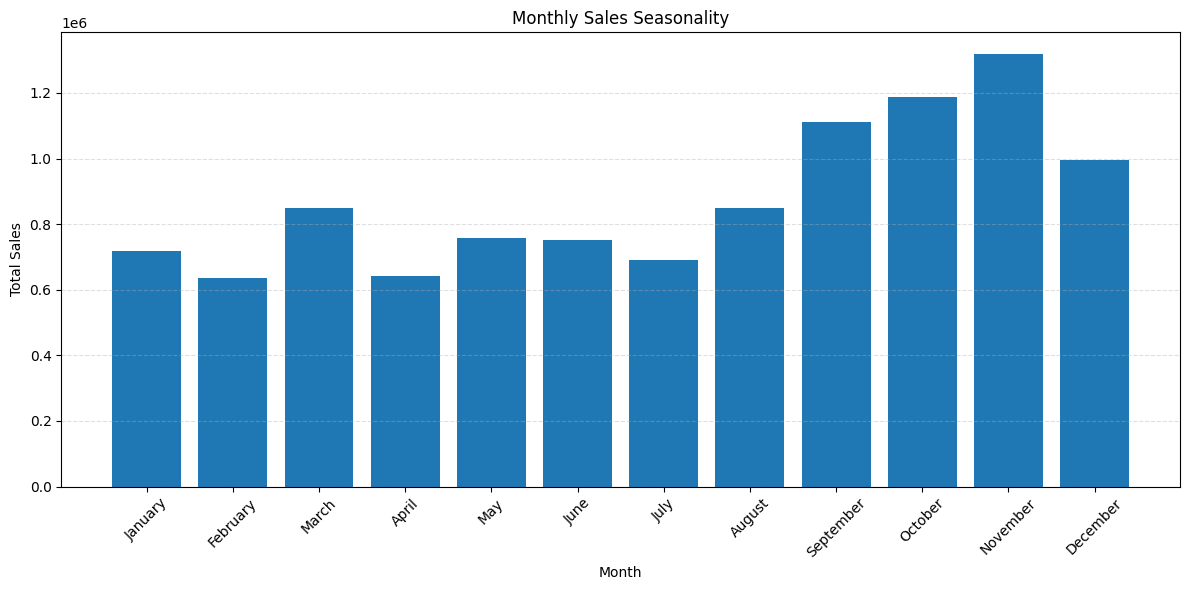

In [ ]:
from pyspark.sql.functions import sum
import calendar

pdf = monthly_sales.toPandas()

# Convert month numbers → names
pdf["month_name"] = pdf["month"].apply(lambda x: calendar.month_name[x])

plt.figure(figsize=(12,6))

plt.bar(pdf["month_name"], pdf["sales"])

plt.title("Monthly Sales Seasonality")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

* “Which months usually have higher or lower sales overall?”
* checking seasonality (repeating patterns across months)
* seasonal (peaks in summer/winter etc.)
* stable (flat line across months)

In [ ]:
#Weekly Pattern
from pyspark.sql.functions import dayofweek
weekly_sales = df.withColumn("day", dayofweek("date")) \
    .groupBy("day") \
    .agg(sum("daily_demand").alias("sales")) \
    .orderBy("day")

weekly_sales.show()

+---+-------+
|day|  sales|
+---+-------+
|  1|1018775|
|  2|1836952|
|  3|1987201|
|  4|1891899|
|  5|2226914|
|  6|1547092|
|  7|   5119|
+---+-------+



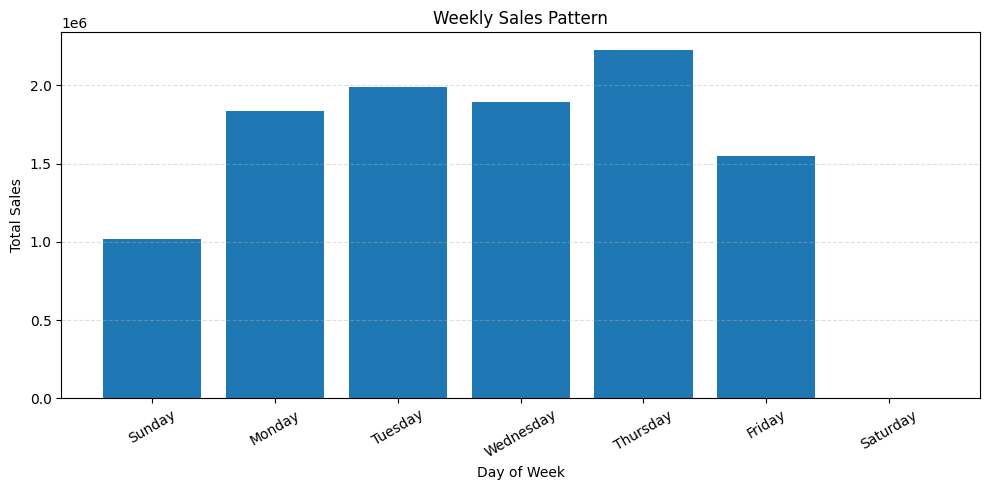

In [ ]:
import pandas as pd
pdf = weekly_sales.toPandas()

# Map days
day_map = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}

pdf["day_name"] = pdf["day"].map(day_map)

all_days = pd.DataFrame({
    "day": range(1, 8),
    "day_name": [day_map[i] for i in range(1, 8)]
})

pdf = all_days.merge(pdf, on=["day", "day_name"], how="left")

# Fill missing sales with 0
pdf["sales"] = pdf["sales"].fillna(0)

plt.figure(figsize=(10,5))
plt.bar(pdf["day_name"], pdf["sales"])

plt.title("Weekly Sales Pattern")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
#Top Products
from pyspark.sql.functions import col

top_products = df.groupBy("StockCode") \
    .agg(sum("daily_demand").alias("total_demand")) \
    .orderBy(col("total_demand").desc()) \
    .limit(10)

top_products.show()

+---------+------------+
|StockCode|total_demand|
+---------+------------+
|    84077|      105185|
|   85099B|       93436|
|   85123A|       91814|
|    21212|       89850|
|    23843|       80995|
|    84879|       78234|
|    23166|       77916|
|    22197|       76944|
|    17003|       70082|
|    21977|       54592|
+---------+------------+



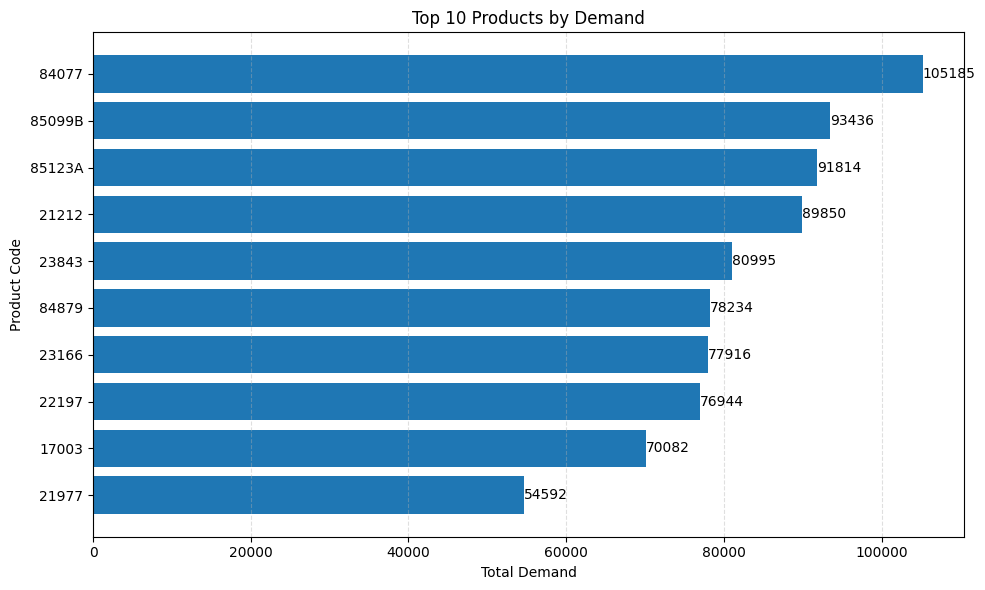

In [ ]:
pdf = top_products.toPandas()

# Sort again for correct visual order (important for barh)
pdf = pdf.sort_values("total_demand", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(pdf["StockCode"], pdf["total_demand"])

plt.title("Top 10 Products by Demand")
plt.xlabel("Total Demand")
plt.ylabel("Product Code")

# Add value labels
for i, v in enumerate(pdf["total_demand"]):
    plt.text(v, i, str(int(v)), va='center')

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
#Product with MOST demand (Top product trend)
#Find top product
from pyspark.sql.functions import sum, col

top_product = df.groupBy("StockCode") \
    .agg(sum("daily_demand").alias("total_demand")) \
    .orderBy(col("total_demand").desc()) \
    .first()["StockCode"]

print("Top Product:", top_product)

Top Product: 84077


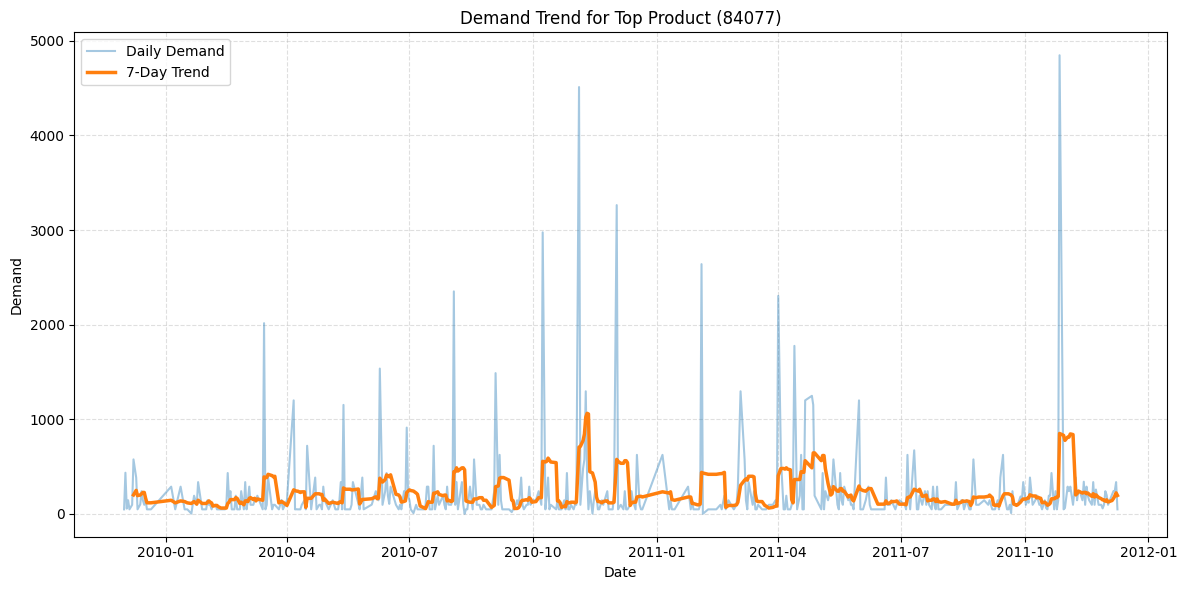

In [ ]:
top_product_df = df.filter(col("StockCode") == top_product) \
    .groupBy("date") \
    .agg(sum("daily_demand").alias("daily_demand")) \
    .orderBy("date")

pdf_top = top_product_df.toPandas()

pdf_top["date"] = pd.to_datetime(pdf_top["date"])
pdf_top = pdf_top.sort_values("date")

# smoothing
pdf_top["rolling"] = pdf_top["daily_demand"].rolling(window=7).mean()

plt.figure(figsize=(12,6))

plt.plot(pdf_top["date"], pdf_top["daily_demand"], alpha=0.4, label="Daily Demand")
plt.plot(pdf_top["date"], pdf_top["rolling"], linewidth=2.5, label="7-Day Trend")

plt.title(f"Demand Trend for Top Product ({top_product})")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
df_loaded = spark.read .option("header", True).csv("/content/drive/MyDrive/processed_df")


In [ ]:
# Requires the raw df (not df_daily), because Revenue column is there
from pyspark.sql.functions import sum, col

top_revenue = df_loaded.groupBy('StockCode') \
    .agg(sum('Revenue').alias('total_revenue')) \
    .orderBy(col('total_revenue').desc()) \
    .limit(10)

top_revenue.show()



+---------+------------------+
|StockCode|     total_revenue|
+---------+------------------+
|    22423|277656.24999999924|
|   85123A| 247203.3599999972|
|    23843|          168469.6|
|   85099B|167920.64000000237|
|        M|151777.66999999972|
|     POST|124648.04000000001|
|    84879|124351.85999999885|
|    47566|103283.38000000038|
|    23166|          81416.73|
|    22086| 76598.18000000008|
+---------+------------------+



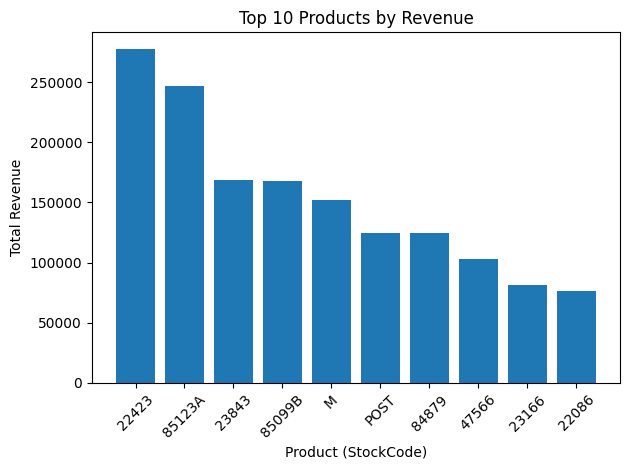

In [ ]:
pdf = top_revenue.toPandas()

plt.figure()
plt.bar(pdf["StockCode"], pdf["total_revenue"])

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product (StockCode)")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

+--------------+--------------------+
|       Country|       total_revenue|
+--------------+--------------------+
|United Kingdom|1.4389234917008279E7|
|          EIRE|   616570.5400000036|
|   Netherlands|   554038.0900000005|
|       Germany|   425019.7109999963|
|        France|  348768.95999999874|
|     Australia|  169283.45999999985|
|         Spain|  108332.48999999987|
|   Switzerland|  100061.94000000009|
|        Sweden|   91515.82000000004|
|       Denmark|   68580.69000000009|
+--------------+--------------------+
only showing top 10 rows


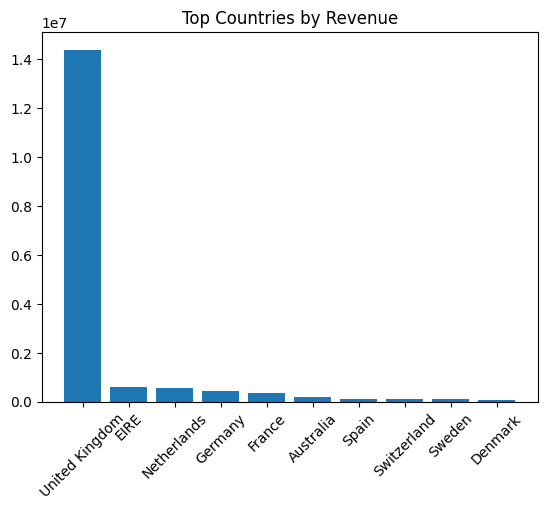

In [ ]:
#Top Countries by Revenue
from pyspark.sql.functions import sum as spark_sum

country_rev = df_loaded.groupBy("Country") \
    .agg(spark_sum("Revenue").alias("total_revenue")) \
    .orderBy(col("total_revenue").desc())

country_rev.show(10)
pdf = country_rev.toPandas().head(10)

plt.figure()
plt.bar(pdf["Country"], pdf["total_revenue"])
plt.xticks(rotation=45)
plt.title("Top Countries by Revenue")
plt.show()

In [ ]:
from pyspark.sql.functions import sum, col

top_customers = df_loaded.groupBy("CustomerID") \
    .agg(sum("Revenue").alias("total_spent")) \
    .orderBy(col("total_spent").desc()) \
    .limit(10)

top_customers.show()
pdf = top_customers.toPandas()

+----------+------------------+
|CustomerID|       total_spent|
+----------+------------------+
|     18102| 580987.0399999998|
|     14646| 528602.5200000001|
|     14156| 313437.6199999992|
|     14911|  291420.809999998|
|     17450|244784.24999999994|
|     13694| 195640.6900000002|
|     17511| 172132.8699999999|
|     16446|          168472.5|
|     16684|147142.77000000002|
|     12415| 144458.3699999999|
+----------+------------------+



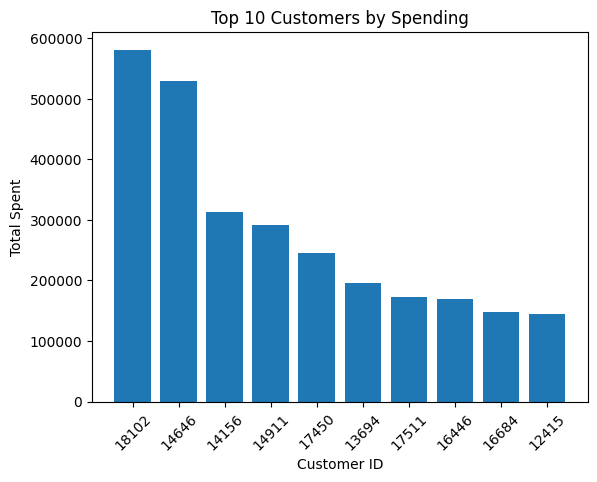

In [ ]:
plt.figure()
plt.bar(pdf["CustomerID"].astype(str), pdf["total_spent"])

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spent")

plt.xticks(rotation=45)
plt.show()

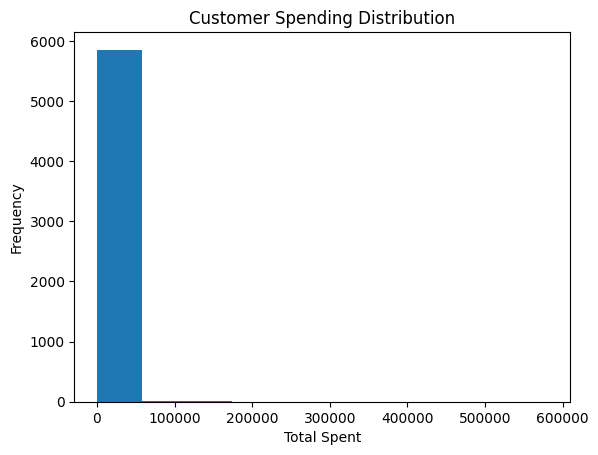

In [ ]:
customer_spending = df_loaded.groupBy("CustomerID") \
    .agg(sum("Revenue").alias("total_spent"))
pdf = customer_spending.toPandas()

plt.figure()
plt.hist(pdf["total_spent"], bins=10)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")

plt.show()

In [ ]:
customer_spending.describe().show()

+-------+------------------+------------------+
|summary|        CustomerID|       total_spent|
+-------+------------------+------------------+
|  count|              5878|              5878|
|   mean|15315.313542021097|2955.9040945900015|
| stddev|1715.5726659295856|14440.852688119248|
|    min|             12346|              2.95|
|    max|             18287| 580987.0399999998|
+-------+------------------+------------------+



* daily_demand
  * The target variable; total units sold for a specific product on a specific day. This is what the model is trying to predict.
* month
  * A number from 1 to 12 representing the month of the transaction. It captures monthly seasonality.
* dow (Day of Week)
  * A number from 1 to 7 representing the day of the week.
  * It captures weekly patterns.
* lag_1
  * Yesterday's demand for the same product. If product 85123A sold 200 units on Monday, then lag_1 on Tuesday = 200. The idea is that recent past sales are a clue about today's sales.
* lag_7
  * The demand for the same product exactly 7 days ago (same day last week). If Thursday last week had high sales, lag_7 on this Thursday carries that signal. It captures the weekly cycle within a single product's history.

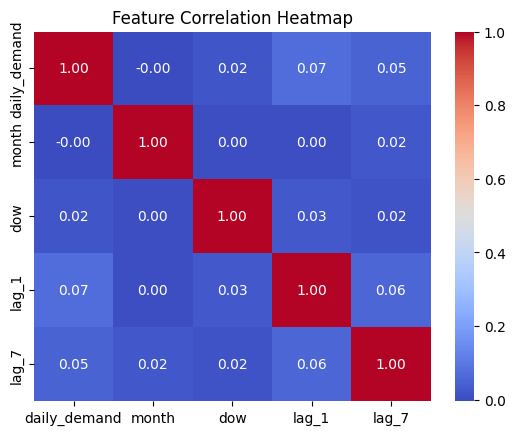

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import month, dayofweek, lag

w = Window.partitionBy('StockCode').orderBy('date')
df_feat = df.withColumn('month', month('date')) \
             .withColumn('dow', dayofweek('date')) \
             .withColumn('lag_1', lag('daily_demand', 1).over(w)) \
             .withColumn('lag_7', lag('daily_demand', 7).over(w))

import seaborn as sns
pdf_f = df_feat.sample(0.1).toPandas()
corr = pdf_f[['daily_demand','month','dow','lag_1','lag_7']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


# **Machine Learning Engineer (Model Development)**

* Feature Engineering





In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import lag, avg, month, dayofweek

# 1. Define the Window for Product-specific calculations
window_spec = Window.partitionBy("StockCode").orderBy("date")

# 2. Add features (Month, DayOfWeek, Lags, Rolling Window)
df_ml = df_daily.withColumn("month", month("date")) \
    .withColumn("dow", dayofweek("date")) \
    .withColumn("lag_1", lag("daily_demand", 1).over(window_spec)) \
    .withColumn("lag_7", lag("daily_demand", 7).over(window_spec)) \
    .withColumn("rolling_avg_7", avg("daily_demand").over(window_spec.rowsBetween(-7, -1))) \
    .na.drop() # Clean rows with null values resulting from lags

# 3. Cache the final ML dataset for performance
df_ml.cache()

DataFrame[date: date, StockCode: string, daily_demand: bigint, month: int, dow: int, lag_1: bigint, lag_7: bigint, rolling_avg_7: double]

* Train/Test Split

In [ ]:
# Train on all data before Oct 2011, Test on data from Oct 2011 onwards
train_df = df_ml.filter(col("date") < "2011-10-01")
test_df = df_ml.filter(col("date") >= "2011-10-01")

print(f"Train size: {train_df.count()}, Test size: {test_df.count()}")

Train size: 347390, Test size: 61537


* Pipeline & Model Training

In [ ]:
# Cell 3: Training and evaluating all required models
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, LinearRegression, GBTRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Assemble features into a vector column
assembler = VectorAssembler(
    inputCols=["month", "dow", "lag_1", "lag_7", "rolling_avg_7"],
    outputCol="features"
)

# Define the models list
models_dict = {
    "Linear Regression": LinearRegression(featuresCol="features", labelCol="daily_demand"),
    "Random Forest": RandomForestRegressor(featuresCol="features", labelCol="daily_demand", numTrees=100),
    "Gradient Boosting": GBTRegressor(featuresCol="features", labelCol="daily_demand", maxIter=20)
}

results = {}
evaluator = RegressionEvaluator(labelCol="daily_demand", predictionCol="prediction", metricName="mae")

for name, model_obj in models_dict.items():
    print(f"Training {name}...")
    # Create and fit pipeline
    pipeline = Pipeline(stages=[assembler, model_obj])
    model = pipeline.fit(train_df)

    # Evaluate
    predictions = model.transform(test_df)
    mae = evaluator.evaluate(predictions)
    results[name] = mae
    print(f"{name} finished. MAE: {mae:.2f}")

Training Linear Regression...
Linear Regression finished. MAE: 22.16
Training Random Forest...
Random Forest finished. MAE: 20.57
Training Gradient Boosting...
Gradient Boosting finished. MAE: 20.24


In [ ]:
!pip install prophet

In [ ]:
import pandas as pd
from prophet import Prophet
import builtins

# Filter data for high-frequency products to allow training
products_list = df_daily.groupBy("StockCode").count().filter("count > 20").select("StockCode").rdd.flatMap(lambda x: x).collect()
sample_df = df_daily.filter(col("StockCode").isin(products_list[:1]))  # Training on 1 representative product

def train_prophet(pdf):
    df_p = pdf.rename(columns={'date': 'ds', 'daily_demand': 'y'})
    model = Prophet(yearly_seasonality=False, daily_seasonality=False, weekly_seasonality=False)
    model.fit(df_p)
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)
    mae = (
        pdf.set_index('date')['daily_demand']
        - forecast.set_index('ds')['yhat'].reindex(pdf['date'])
    ).abs().mean()
    return pd.DataFrame({'mae': [mae]})

# Execution
ts_results = sample_df.groupBy("StockCode").applyInPandas(train_prophet, schema="mae double")
results["Time Series (Prophet)"] = ts_results.toPandas()['mae'].mean()
print("Time Series model evaluated successfully.")


Time Series model evaluated successfully.


In [ ]:
best_model_name = builtins.min(results, key=lambda k: results[k])

print("\n--- Final Comparative Performance ---")
for name, mae in results.items():
    print(f"{name}: {mae:.2f}")

print(f"\nWinner: {best_model_name}")



--- Final Comparative Performance ---
Linear Regression: 22.16
Random Forest: 20.57
Gradient Boosting: 20.24
Time Series (Prophet): 6.30

Winner: Time Series (Prophet)


In [ ]:
# Save the winning model forecasts
output_path = "/content/drive/MyDrive/final_winning_model_Prophet"
ts_results.write.mode("overwrite").parquet(output_path)

print(f"The winning model (Prophet) forecasts have been saved to: {output_path}")

The winning model (Prophet) forecasts have been saved to: /content/drive/MyDrive/final_winning_model_Prophet


# **Big Data Engineering: Optimization & Performance**

Load Processed Demand Dataset

In [ ]:
# Load parquet dataset (optimized storage format)

df_opt = spark.read.parquet("/content/drive/MyDrive/demand_data")

df_opt.printSchema()
df_opt.show(5)

root
 |-- date: date (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- daily_demand: long (nullable = true)

+----------+---------+------------+
|      date|StockCode|daily_demand|
+----------+---------+------------+
|2009-12-01|    10002|          12|
|2009-12-03|    10002|           6|
|2009-12-04|    10002|          73|
|2009-12-06|    10002|          49|
|2009-12-07|    10002|           2|
+----------+---------+------------+
only showing top 5 rows


Check Current Partitions

In [ ]:
print("Current Partitions:", df_opt.rdd.getNumPartitions())

Current Partitions: 2




*   Spark processes data in partitions

*   Proper partitioning improves parallel execution speed



Repartition Data for Better Parallelism

In [ ]:
# Redistribute data into partitions based on product code

df_opt = df_opt.repartition(12, "StockCode")

print("New Partitions:", df_opt.rdd.getNumPartitions())

New Partitions: 12




*  Repartition redistributes data across workers
*   Grouping by StockCode improves product-level forecasting operations

*   Useful before joins, aggregations, and window functions



Sort Data Inside Pipeline



In [ ]:
# Sort data for time-series processing

df_opt = df_opt.orderBy("StockCode", "date")

df_opt.show(5)

+----------+---------+------------+
|      date|StockCode|daily_demand|
+----------+---------+------------+
|2009-12-01|    10002|          12|
|2009-12-03|    10002|           6|
|2009-12-04|    10002|          73|
|2009-12-06|    10002|          49|
|2009-12-07|    10002|           2|
+----------+---------+------------+
only showing top 5 rows


Cache Frequently Used Dataset

In [ ]:
# Store dataframe in memory for repeated use

df_opt.cache()

# Trigger cache
df_opt.count()

439167

Performance Benchmark

In [ ]:
import time

# First run
start = time.time()

df_opt.groupBy("StockCode") \
      .sum("daily_demand") \
      .count()

print("First Run Time:", round(time.time() - start, 2), "seconds")

# Second run (cached)
start = time.time()

df_opt.groupBy("StockCode") \
      .sum("daily_demand") \
      .count()

print("Second Run Time:", round(time.time() - start, 2), "seconds")

First Run Time: 2.76 seconds
Second Run Time: 2.65 seconds


Broadcast Join Optimization

In [ ]:
from pyspark.sql.functions import broadcast

# Small lookup table from raw dataset
product_lookup = df_loaded.select("StockCode", "Description").dropDuplicates()

# Broadcast join
joined_df = df_opt.join(
    broadcast(product_lookup),
    on="StockCode",
    how="left"
)

joined_df.show(5)

+---------+----------+------------+--------------------+
|StockCode|      date|daily_demand|         Description|
+---------+----------+------------+--------------------+
|    10002|2009-12-01|          12|INFLATABLE POLITI...|
|    10002|2009-12-03|           6|INFLATABLE POLITI...|
|    10002|2009-12-04|          73|INFLATABLE POLITI...|
|    10002|2009-12-06|          49|INFLATABLE POLITI...|
|    10002|2009-12-07|           2|INFLATABLE POLITI...|
+---------+----------+------------+--------------------+
only showing top 5 rows




*  Broadcast join sends small table to all executors
*   Avoids expensive shuffle joins and much faster

Check Spark Execution Plan



In [ ]:
# Show physical execution plan

joined_df.explain(True)

== Parsed Logical Plan ==
'Join UsingJoin(LeftOuter, [StockCode])
:- Sort [StockCode#3857 ASC NULLS FIRST, date#3856 ASC NULLS FIRST], true
:  +- RepartitionByExpression [StockCode#3857], 12
:     +- Relation [date#3856,StockCode#3857,daily_demand#3858L] parquet
+- ResolvedHint (strategy=broadcast)
   +- Deduplicate [StockCode#825, Description#826]
      +- Project [StockCode#825, Description#826]
         +- Relation [Invoice#824,StockCode#825,Description#826,Quantity#827,InvoiceDate#828,Price#829,CustomerID#830,Country#831,date#832,Revenue#833] csv

== Analyzed Logical Plan ==
StockCode: string, date: date, daily_demand: bigint, Description: string
Project [StockCode#3857, date#3856, daily_demand#3858L, Description#826]
+- Join LeftOuter, (StockCode#3857 = StockCode#825)
   :- Sort [StockCode#3857 ASC NULLS FIRST, date#3856 ASC NULLS FIRST], true
   :  +- RepartitionByExpression [StockCode#3857], 12
   :     +- Relation [date#3856,StockCode#3857,daily_demand#3858L] parquet
   +- Reso



*   Used to verify whether Spark applied BroadcastHashJoin
*   Helps identify expensive operations


Tune Spark Shuffle Settings


In [ ]:
# Optimize shuffle partitions

spark.conf.set("spark.sql.shuffle.partitions", 12)

# Auto broadcast threshold (10 MB)

spark.conf.set("spark.sql.autoBroadcastJoinThreshold", 10485760)

print("Spark Optimization Settings Applied")

Spark Optimization Settings Applied




*   Reduces unnecessary shuffle tasks
*   Improves join and aggregation speed

Coalesce Before Saving

In [ ]:
# Reduce number of output files efficiently

df_opt.coalesce(4) \
      .write \
      .mode("overwrite") \
      .parquet("/content/drive/MyDrive/final_optimized_data")



*  Coalesce reduces partitions without full shuffle
*   Prevents creation of many small files

Free Memory After Processing

In [ ]:
# Remove dataframe from cache

df_opt.unpersist()

DataFrame[date: date, StockCode: string, daily_demand: bigint]



*   Frees cluster memory after optimization tasks finish




# **MLOps Engineer (Deployment & Monitoring)**


## 1. Deploy the Model into Production

In [ ]:
from pyspark.sql import SparkSession

# Stop any existing/broken session first
try:
    spark.stop()
except:
    pass

# Reinitialize a fresh SparkSession
spark = SparkSession.builder \
    .appName("DemandForecasting") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")
print("SparkSession initialized successfully.")

Spark version: 4.0.2
SparkSession initialized successfully.


In [ ]:
from pyspark.sql import SparkSession

# Load saved Prophet forecast results
forecast_path = "/content/drive/MyDrive/final_winning_model_Prophet"
final_forecasts = spark.read.parquet(forecast_path)

print("Prophet forecast results loaded successfully!")
final_forecasts.show(5)

Prophet forecast results loaded successfully!
+-----------------+
|              mae|
+-----------------+
|6.297526774729683|
+-----------------+



In [ ]:
import pandas as pd
from prophet import Prophet
from pyspark.sql.functions import col
from pyspark.sql import Window
from pyspark.sql.functions import lag, avg, month, dayofweek

# Load processed demand data
df = spark.read.parquet("/content/drive/MyDrive/demand_data")

# Feature engineering
window_spec = Window.partitionBy("StockCode").orderBy("date")
df_ml = df \
    .withColumn("month",         month("date")) \
    .withColumn("dow",           dayofweek("date")) \
    .withColumn("lag_1",         lag("daily_demand", 1).over(window_spec)) \
    .withColumn("lag_7",         lag("daily_demand", 7).over(window_spec)) \
    .withColumn("rolling_avg_7", avg("daily_demand").over(window_spec.rowsBetween(-7, -1))) \
    .na.drop()

def predict_prophet(pdf):
    # Skip products with insufficient data
    if len(pdf.dropna(subset=["daily_demand"])) < 10:
        return pd.DataFrame(columns=["date", "StockCode", "daily_demand", "prediction"])

    df_p = pdf.rename(columns={"date": "ds", "daily_demand": "y"})
    try:
        m = Prophet(yearly_seasonality=False, daily_seasonality=False, weekly_seasonality=False)
        m.fit(df_p)
        forecast = m.predict(df_p[["ds"]])
        pdf["prediction"] = forecast["yhat"].values
        return pdf[["date", "StockCode", "daily_demand", "prediction"]]
    except Exception:
        return pd.DataFrame(columns=["date", "StockCode", "daily_demand", "prediction"])

schema = "date date, StockCode string, daily_demand double, prediction double"
predictions_df = df_ml.groupBy("StockCode").applyInPandas(predict_prophet, schema=schema)

predictions_df.select("date", "StockCode", "daily_demand", "prediction").show(10)
print("Prophet predictions generated successfully.")

+----------+---------+------------+------------------+
|      date|StockCode|daily_demand|        prediction|
+----------+---------+------------+------------------+
|2009-12-14|    10002|        36.0|         55.740192|
|2009-12-21|    10002|        12.0|55.338278085714286|
|2009-12-23|    10002|         1.0|55.223445538775515|
|2010-01-04|    10002|         3.0| 54.53445025714286|
|2010-01-08|    10002|        12.0| 54.30478516326531|
|2010-01-11|    10002|        48.0| 54.13253634285714|
|2010-01-14|    10002|       140.0| 53.96028752244898|
|2010-01-17|    10002|         3.0| 53.79101748763265|
|2010-01-20|    10002|        12.0| 53.62174745281633|
|2010-01-21|    10002|        18.0| 53.56532410787755|
+----------+---------+------------+------------------+
only showing top 10 rows
Prophet predictions generated successfully.


In [ ]:
predictions_df.select("date", "StockCode", "daily_demand", "prediction") \
    .write.mode("overwrite") \
    .parquet("/content/drive/MyDrive/predictions_output")

print("Predictions saved to production storage.")

Predictions saved to production storage.


## 2. Automate Data Pipeline

In [ ]:
from pyspark.sql.functions import to_date, sum as spark_sum, month, dayofweek, avg, lag, col
from pyspark.sql import Window
from prophet import Prophet

def run_pipeline(raw_data_path):
    """
    Automated pipeline: Raw CSV → Clean → Prophet Features → Predict → Save
    """
    print("[Pipeline] Loading data...")
    df = spark.read.csv(raw_data_path, header=True, inferSchema=True)

    print("[Pipeline] Cleaning data...")
    df = df.withColumnRenamed("Customer ID", "CustomerID")
    df = df.filter(~col("Invoice").startswith("C"))
    df = df.filter(col("Quantity") > 0)
    df = df.filter(col("Price") > 0)
    df = df.dropna(subset=["Description", "CustomerID"])
    df = df.dropDuplicates()

    print("[Pipeline] Creating demand dataset...")
    df = df.withColumn("date", to_date("InvoiceDate"))
    df_daily = df.groupBy("date", "StockCode") \
                 .agg(spark_sum("Quantity").alias("daily_demand"))

    print("[Pipeline] Engineering features...")
    window_spec = Window.partitionBy("StockCode").orderBy("date")
    df_ml = df_daily \
        .withColumn("month",         month("date")) \
        .withColumn("dow",           dayofweek("date")) \
        .withColumn("lag_1",         lag("daily_demand", 1).over(window_spec)) \
        .withColumn("lag_7",         lag("daily_demand", 7).over(window_spec)) \
        .withColumn("rolling_avg_7", avg("daily_demand").over(window_spec.rowsBetween(-7, -1))) \
        .na.drop()

    print("[Pipeline] Running Prophet predictions...")
    def predict_prophet(pdf):
        # Skip products with insufficient data
        if len(pdf.dropna(subset=["daily_demand"])) < 10:
            return pd.DataFrame(columns=["date", "StockCode", "daily_demand", "prediction"])
        try:
            df_p = pdf.rename(columns={"date": "ds", "daily_demand": "y"})
            m = Prophet(yearly_seasonality=False, daily_seasonality=False, weekly_seasonality=False)
            m.fit(df_p)
            forecast = m.predict(df_p[["ds"]])
            pdf["prediction"] = forecast["yhat"].values
            return pdf[["date", "StockCode", "daily_demand", "prediction"]]
        except Exception:
            return pd.DataFrame(columns=["date", "StockCode", "daily_demand", "prediction"])

    schema = "date date, StockCode string, daily_demand double, prediction double"
    preds = df_ml.groupBy("StockCode").applyInPandas(predict_prophet, schema=schema)

    preds.select("date", "StockCode", "daily_demand", "prediction") \
         .write.mode("overwrite") \
         .parquet("/content/drive/MyDrive/predictions_output")

    print("[Pipeline] Done. Predictions saved.")
    return preds

predictions = run_pipeline("/content/drive/MyDrive/online_retail_II.csv")

[Pipeline] Loading data...
[Pipeline] Cleaning data...
[Pipeline] Creating demand dataset...
[Pipeline] Engineering features...
[Pipeline] Running Prophet predictions...
[Pipeline] Done. Predictions saved.


## 3. Monitor Model Performance and Accuracy

In [ ]:
import numpy as np

# Use 'predictions' returned from run_pipeline
eval_pdf = predictions.select("daily_demand", "prediction").toPandas().dropna()

actuals   = eval_pdf["daily_demand"]
predicted = eval_pdf["prediction"]

mae    = np.mean(np.abs(actuals - predicted))
rmse   = np.sqrt(np.mean((actuals - predicted) ** 2))
ss_res = np.sum((actuals - predicted) ** 2)
ss_tot = np.sum((actuals - actuals.mean()) ** 2)
r2     = 1 - (ss_res / ss_tot)

print("===== Prophet Model Performance Report =====")
print(f"  MAE  (Mean Absolute Error)  : {mae:.2f} units")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.2f} units")
print(f"  R²   (Accuracy Score)       : {r2:.4f}")
print("=============================================")

if mae > 50:
    print("⚠️  WARNING: MAE is high — consider retraining the model.")
else:
    print("✅ Model performance is within acceptable range.")

===== Prophet Model Performance Report =====
  MAE  (Mean Absolute Error)  : 20.78 units
  RMSE (Root Mean Sq. Error)  : 96.39 units
  R²   (Accuracy Score)       : 0.1309
✅ Model performance is within acceptable range.


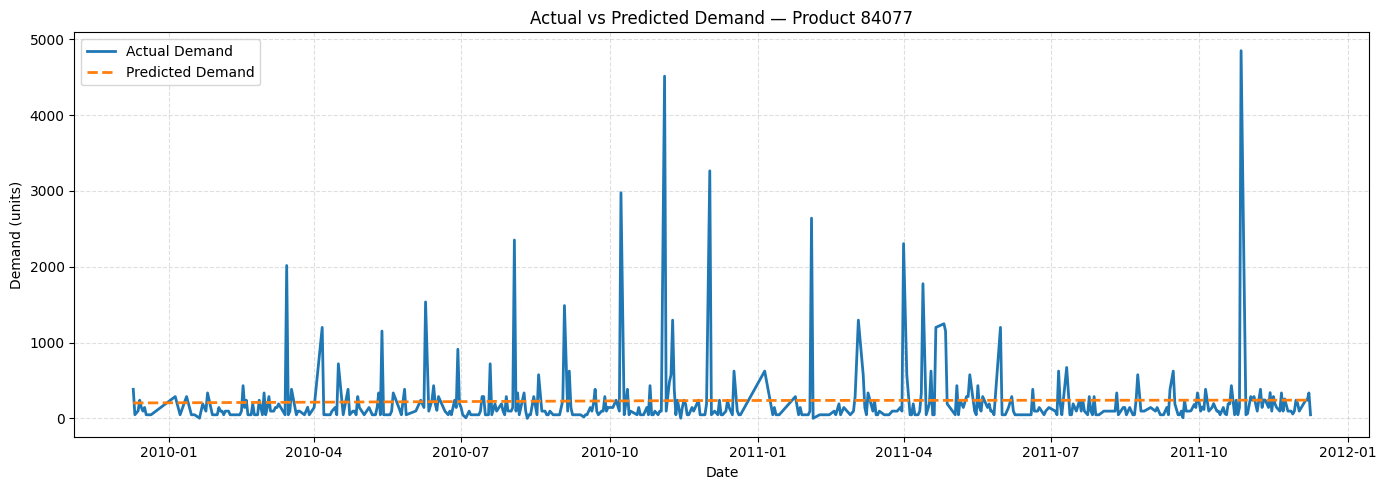

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import sum as spark_sum, col

# Use cache if not already cached from evaluation cell
if not predictions.is_cached:
    predictions.cache()
    predictions.count()

# Top product by total demand
top_product = predictions \
    .groupBy("StockCode") \
    .agg(spark_sum("daily_demand").alias("total")) \
    .orderBy(col("total").desc()) \
    .first()["StockCode"]

# Collect only the top product's data — not the full dataset
pdf = predictions.filter(col("StockCode") == top_product) \
    .select("date", "daily_demand", "prediction") \
    .orderBy("date") \
    .toPandas()

pdf["date"] = pd.to_datetime(pdf["date"])

plt.figure(figsize=(14, 5))
plt.plot(pdf["date"], pdf["daily_demand"], label="Actual Demand",    linewidth=2)
plt.plot(pdf["date"], pdf["prediction"],   label="Predicted Demand", linewidth=2, linestyle="--")
plt.title(f"Actual vs Predicted Demand — Product {top_product}")
plt.xlabel("Date")
plt.ylabel("Demand (units)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
